# Robustness 4-Variant Analysis: Dependency Distance Autocorrelation

This notebook demonstrates a **4-variant robustness analysis** of dependency distance (DD) autocorrelation across typologically diverse Universal Dependencies treebanks.

**Four pipeline variants** are tested:
- **A**: Punctuation excluded, sentences >= 20 tokens (primary)
- **B**: Punctuation included, sentences >= 20 tokens
- **C**: Punctuation excluded, sentences >= 15 tokens (lower threshold)
- **D**: Punctuation excluded, sentences >= 20 tokens, projective trees only

For each sentence, observed lag-1 autocorrelation of DD sequences is compared against a **Random Projective Linearization (RPL)** baseline. The "excess" (observed minus baseline) measures whether real word order produces more anti-correlated DD sequences than expected by chance.

Results are aggregated via **DerSimonian-Laird meta-analysis** across treebanks, with pairwise variant comparisons and concrete compensatory-pattern examples.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed — all deps are pre-installed on Colab

# Core packages: pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.15.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import time
from collections import defaultdict

import numpy as np
from scipy.stats import t as t_dist, wilcoxon, norm
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-c3cfa4-sequential-dependency-distance-anti-corr/main/experiment_iter3_robustness_4_va/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['treebanks'])} treebanks:")
for tb_id, info in data["treebanks"].items():
    print(f"  {tb_id}: {info['language']} ({info['family']}), {len(info['sentences'])} sentences")

Loaded 9 treebanks:
  af_afribooms: Afrikaans (Indo-European), 8 sentences
  akk_riao: Akkadian (Afro-Asiatic), 8 sentences
  ar_padt: Arabic (Afro-Asiatic), 8 sentences
  en_ewt: English (Indo-European), 8 sentences
  eu_bdt: Basque (Basque), 8 sentences
  fi_tdt: Finnish (Uralic), 8 sentences
  grc_perseus: Ancient Greek (Indo-European), 8 sentences
  hbo_ptnk: Ancient Hebrew (Afro-Asiatic), 8 sentences
  zh_gsd: Chinese (Sino-Tibetan), 8 sentences


## Configuration

All tunable parameters for the analysis. Adjust these to trade off between speed and statistical power.

In [5]:
# --- Tunable parameters ---
# Number of Random Projective Linearization permutations per sentence
N_PERMS = 100              # Original: 100

# Minimum sentences per treebank to include in meta-analysis
MIN_SENTENCES_META = 3     # Original: 30 (lowered for demo's smaller dataset)

# Minimum sentences for any variant estimate
MIN_SENTENCES_EFFECT = 2   # Original: 10 (lowered for demo's smaller dataset)

# Number of top treebanks for concrete examples
N_TOP_TREEBANKS = 5        # Original: 5

# Number of example sentences per top treebank
N_EXAMPLES_PER = 10        # Original: 10

# Number of RPL permutations for example selection (lighter)
N_PERMS_EXAMPLES = 30      # Original: 30

## Core Computation Functions

Dependency distance (DD) sequences, projectivity checking, random projective linearization (RPL), and lag-1 autocorrelation.

In [6]:
def compute_dd_punct_excluded(head_array, deprel_array):
    """Compute DD sequence excluding punctuation tokens."""
    dd_seq = []
    for i in range(len(head_array)):
        if deprel_array[i] == "punct":
            continue
        h = head_array[i]
        if h == 0:
            continue
        dd_seq.append(abs((i + 1) - h))
    return dd_seq


def compute_dd_punct_included(head_array):
    """Original DD sequence including all non-root tokens."""
    dd_seq = []
    for i in range(len(head_array)):
        h = head_array[i]
        if h == 0:
            continue
        dd_seq.append(abs((i + 1) - h))
    return dd_seq


def check_projectivity(head_array):
    """Check if dependency tree has no crossing arcs."""
    n = len(head_array)
    for i in range(n):
        h = head_array[i]
        if h == 0:
            continue
        pos = i + 1
        lo, hi = min(pos, h), max(pos, h)
        for j_pos in range(lo + 1, hi):
            hj = head_array[j_pos - 1]
            if hj < lo or hj > hi:
                return False
    return True


def build_children_map(head_array):
    """Build parent->children mapping. Returns (root_0based, children_dict)."""
    children = defaultdict(list)
    root = None
    for i, h in enumerate(head_array):
        if h == 0:
            root = i
        else:
            children[h - 1].append(i)
    return root, children


def _rpl_recursive(node, children, rng):
    """Recursive RPL helper — produce a random projective linearization."""
    child_list = children.get(node, [])
    if not child_list:
        return [node]
    subtrees = [_rpl_recursive(c, children, rng) for c in child_list]
    items = list(subtrees) + [None]
    rng.shuffle(items)
    result = []
    for it in items:
        if it is None:
            result.append(node)
        else:
            result.extend(it)
    return result


def compute_dd_from_linearization(order, head_array, deprel_array, exclude_punct):
    """Compute DD sequence from a random linearization."""
    pos_map = {}
    for new_pos_0, orig_idx in enumerate(order):
        pos_map[orig_idx] = new_pos_0 + 1
    dd_seq = []
    for orig_idx in order:
        if exclude_punct and deprel_array[orig_idx] == "punct":
            continue
        h = head_array[orig_idx]
        if h == 0:
            continue
        head_orig_idx = h - 1
        dd = abs(pos_map[orig_idx] - pos_map[head_orig_idx])
        dd_seq.append(dd)
    return dd_seq


def lag1_autocorrelation(seq):
    """Standard Yule-Walker lag-1 autocorrelation (r1)."""
    if len(seq) < 4:
        return float("nan")
    x = np.array(seq, dtype=np.float64)
    x_bar = x.mean()
    denom = np.sum((x - x_bar) ** 2)
    if denom == 0:
        return 0.0
    numer = np.sum((x[:-1] - x_bar) * (x[1:] - x_bar))
    return float(numer / denom)

print("Core computation functions defined.")

Core computation functions defined.


## Per-Sentence 4-Variant Processing

Each sentence is processed for all 4 variants (A/B/C/D) simultaneously. For each variant, the observed lag-1 autocorrelation is compared to a baseline computed from RPL permutations.

In [7]:
def process_sentence_all_variants(head_array, deprel_array, dd_sequence_original,
                                   token_count, n_perms=N_PERMS, rng=None):
    """Process one sentence for all 4 variants. Returns dict with keys A/B/C/D."""
    rng = rng or np.random.default_rng()
    results = {}

    is_ge20 = token_count >= 20
    is_ge15 = token_count >= 15
    is_projective = check_projectivity(head_array)

    # Compute observed DD sequences
    dd_punct_excl = compute_dd_punct_excluded(head_array, deprel_array)
    dd_punct_incl = dd_sequence_original

    r1_obs_excl = lag1_autocorrelation(dd_punct_excl) if len(dd_punct_excl) >= 4 else float("nan")
    r1_obs_incl = lag1_autocorrelation(dd_punct_incl) if len(dd_punct_incl) >= 4 else float("nan")

    # Build tree for RPL
    root, children = build_children_map(head_array)
    if root is None:
        return {}

    # Generate RPL permutations
    rpl_r1_excl = []
    rpl_r1_incl = []
    for _ in range(n_perms):
        try:
            order = _rpl_recursive(root, children, rng)
        except RecursionError:
            continue
        if len(order) != len(head_array):
            continue
        dd_rpl_excl = compute_dd_from_linearization(order, head_array, deprel_array, True)
        dd_rpl_incl = compute_dd_from_linearization(order, head_array, deprel_array, False)
        if len(dd_rpl_excl) >= 4:
            rpl_r1_excl.append(lag1_autocorrelation(dd_rpl_excl))
        if len(dd_rpl_incl) >= 4:
            rpl_r1_incl.append(lag1_autocorrelation(dd_rpl_incl))

    mean_rpl_excl = float(np.nanmean(rpl_r1_excl)) if rpl_r1_excl else float("nan")
    mean_rpl_incl = float(np.nanmean(rpl_r1_incl)) if rpl_r1_incl else float("nan")

    # Variant A: punct excluded, >=20 tokens
    if is_ge20 and not np.isnan(r1_obs_excl) and not np.isnan(mean_rpl_excl):
        results["A"] = {
            "observed_r1": r1_obs_excl, "baseline_r1": mean_rpl_excl,
            "excess": r1_obs_excl - mean_rpl_excl, "dd_length": len(dd_punct_excl),
        }
    # Variant B: punct included, >=20 tokens
    if is_ge20 and not np.isnan(r1_obs_incl) and not np.isnan(mean_rpl_incl):
        results["B"] = {
            "observed_r1": r1_obs_incl, "baseline_r1": mean_rpl_incl,
            "excess": r1_obs_incl - mean_rpl_incl, "dd_length": len(dd_punct_incl),
        }
    # Variant C: punct excluded, >=15 tokens
    if is_ge15 and not np.isnan(r1_obs_excl) and not np.isnan(mean_rpl_excl):
        results["C"] = {
            "observed_r1": r1_obs_excl, "baseline_r1": mean_rpl_excl,
            "excess": r1_obs_excl - mean_rpl_excl, "dd_length": len(dd_punct_excl),
        }
    # Variant D: punct excluded, >=20 tokens, projective only
    if is_ge20 and is_projective and not np.isnan(r1_obs_excl) and not np.isnan(mean_rpl_excl):
        results["D"] = {
            "observed_r1": r1_obs_excl, "baseline_r1": mean_rpl_excl,
            "excess": r1_obs_excl - mean_rpl_excl, "dd_length": len(dd_punct_excl),
        }
    return results


def process_treebank(treebank_id, sentences, n_perms=N_PERMS):
    """Process all sentences for one treebank, all 4 variants."""
    rng = np.random.default_rng(hash(treebank_id) % (2**32))
    variant_results = {v: [] for v in ["A", "B", "C", "D"]}
    n_skipped = 0

    for sent in sentences:
        try:
            results = process_sentence_all_variants(
                sent["head_array"], sent["deprel_array"],
                sent["dd_sequence"], sent["token_count"], n_perms, rng,
            )
            for v, res in results.items():
                variant_results[v].append(res)
        except Exception:
            n_skipped += 1
            continue

    # Aggregate per treebank per variant
    treebank_summary = {"n_skipped": n_skipped}
    for v in ["A", "B", "C", "D"]:
        vals = variant_results[v]
        if len(vals) < MIN_SENTENCES_EFFECT:
            treebank_summary[v] = None
            continue
        excess_arr = np.array([r["excess"] for r in vals])
        treebank_summary[v] = {
            "n_sentences": len(vals),
            "mean_excess": float(np.mean(excess_arr)),
            "var_excess": float(np.var(excess_arr, ddof=1)),
            "se_excess": float(np.std(excess_arr, ddof=1) / np.sqrt(len(vals))),
            "median_excess": float(np.median(excess_arr)),
            "prop_negative": float(np.mean(excess_arr < 0)),
            "iqr_excess": float(np.percentile(excess_arr, 75) - np.percentile(excess_arr, 25)),
            "mean_observed_r1": float(np.mean([r["observed_r1"] for r in vals])),
            "mean_baseline_r1": float(np.mean([r["baseline_r1"] for r in vals])),
            "mean_dd_length": float(np.mean([r["dd_length"] for r in vals])),
        }
    return treebank_summary

print("Sentence and treebank processing functions defined.")

Sentence and treebank processing functions defined.


## Meta-Analysis (DerSimonian-Laird)

Pool effect sizes across treebanks using the DerSimonian-Laird random-effects meta-analysis estimator. Computes pooled estimates, confidence intervals, heterogeneity (I-squared), and prediction intervals.

In [8]:
def run_meta_analysis(treebank_results, variant_key):
    """Run DerSimonian-Laird meta-analysis for one variant across treebanks."""
    effect_sizes = []
    variances = []
    treebank_ids = []

    for tb_id, results in treebank_results.items():
        r = results.get(variant_key)
        if r is None:
            continue
        if r["n_sentences"] < MIN_SENTENCES_META:
            continue
        effect_sizes.append(r["mean_excess"])
        variances.append(r["var_excess"] / r["n_sentences"])
        treebank_ids.append(tb_id)

    if len(effect_sizes) < 3:
        return {"error": f"Too few treebanks ({len(effect_sizes)})"}

    y = np.array(effect_sizes)
    v = np.maximum(np.array(variances), 1e-12)
    K = len(y)

    # DerSimonian-Laird estimator
    w = 1.0 / v
    theta_fe = np.sum(w * y) / np.sum(w)
    Q = np.sum(w * (y - theta_fe) ** 2)
    c = np.sum(w) - np.sum(w**2) / np.sum(w)
    tau2 = max(0.0, float((Q - (K - 1)) / c))
    w_re = 1.0 / (v + tau2)
    pooled = float(np.sum(w_re * y) / np.sum(w_re))
    se_re = float(1.0 / np.sqrt(np.sum(w_re)))
    ci_low = float(pooled - 1.96 * se_re)
    ci_up = float(pooled + 1.96 * se_re)
    z = pooled / se_re if se_re > 0 else 0
    p_val = float(2 * (1 - norm.cdf(abs(z))))

    # Heterogeneity
    I2 = tau2 / (tau2 + np.mean(v)) if (tau2 + np.mean(v)) > 0 else 0.0

    # Prediction interval
    try:
        pi_half = t_dist.ppf(0.975, max(K - 2, 1)) * np.sqrt(se_re**2 + tau2)
        pi = [float(pooled - pi_half), float(pooled + pi_half)]
    except Exception:
        pi = [float("nan"), float("nan")]

    return {
        "pooled_estimate": pooled, "pooled_se": se_re,
        "pooled_ci_lower": ci_low, "pooled_ci_upper": ci_up,
        "pooled_p_value": p_val, "tau2": float(tau2), "I2": float(I2),
        "prediction_interval": pi, "K_treebanks": K,
        "per_treebank_effects": {
            tb: {"effect": float(e), "variance": float(va)}
            for tb, e, va in zip(treebank_ids, y, v)
        },
        "median_effect": float(np.median(y)),
        "prop_negative": float(np.mean(y < 0)),
    }


def compute_variant_comparisons(treebank_results, meta_results):
    """Compute pairwise variant comparisons."""
    comparisons = {}

    # A vs B: punctuation effect
    paired_diffs_ab = []
    for tb_id, res in treebank_results.items():
        a = res.get("A")
        b = res.get("B")
        if a is not None and b is not None:
            paired_diffs_ab.append(a["mean_excess"] - b["mean_excess"])

    if len(paired_diffs_ab) >= 5:
        diffs = np.array(paired_diffs_ab)
        try:
            stat, p = wilcoxon(diffs)
        except Exception:
            stat, p = float("nan"), float("nan")
        comparisons["A_vs_B_punct_effect"] = {
            "mean_diff": float(np.mean(diffs)),
            "median_diff": float(np.median(diffs)),
            "CI_95": [float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))],
            "p_wilcoxon": float(p),
            "n_paired": len(diffs),
            "interpretation": (
                "Punctuation exclusion makes excess MORE negative"
                if np.mean(diffs) < 0
                else "Punctuation exclusion makes excess LESS negative"
            ),
        }

    # A vs C: threshold sensitivity
    a_meta = meta_results.get("A", {})
    c_meta = meta_results.get("C", {})
    if "pooled_estimate" in a_meta and "pooled_estimate" in c_meta:
        a_pool = a_meta["pooled_estimate"]
        c_pool = c_meta["pooled_estimate"]
        ratio = c_pool / a_pool if abs(a_pool) > 1e-10 else float("nan")
        comparisons["A_vs_C_threshold_sensitivity"] = {
            "A_pooled": a_pool, "C_pooled": c_pool,
            "ratio_C_over_A": float(ratio),
            "delta_pooled": float(c_pool - a_pool),
        }

    # A vs D: projectivity effect
    d_meta = meta_results.get("D", {})
    if "pooled_estimate" in a_meta and "pooled_estimate" in d_meta:
        a_pool = a_meta["pooled_estimate"]
        d_pool = d_meta["pooled_estimate"]
        n_a = sum(1 for r in treebank_results.values() if r.get("A") is not None)
        n_d = sum(1 for r in treebank_results.values() if r.get("D") is not None)
        comparisons["A_vs_D_projectivity_effect"] = {
            "A_pooled": a_pool, "D_pooled": d_pool,
            "delta_pooled": float(a_pool - d_pool),
            "treebanks_A": n_a, "treebanks_D": n_d,
        }

    return comparisons

print("Meta-analysis and comparison functions defined.")

Meta-analysis and comparison functions defined.


## Concrete Compensatory-Pattern Examples

Extract individual sentences that best illustrate the compensatory anti-correlation pattern: alternating high/low dependency distances.

In [9]:
def extract_concrete_examples(treebank_results, treebank_sentences,
                              n_top=N_TOP_TREEBANKS, n_examples_per=N_EXAMPLES_PER):
    """Extract top example sentences showing compensatory anti-correlation."""
    # Find top-N treebanks by most negative mean_excess (variant A)
    tb_effects = []
    for tb_id, res in treebank_results.items():
        a = res.get("A")
        if a is not None and a["n_sentences"] >= MIN_SENTENCES_META:
            tb_effects.append((tb_id, a["mean_excess"]))

    tb_effects.sort(key=lambda x: x[1])
    top_tbs = [tb_id for tb_id, _ in tb_effects[:n_top]]

    examples = []
    for tb_id in top_tbs:
        sents = treebank_sentences.get(tb_id, [])
        if not sents:
            continue
        rng = np.random.default_rng(hash(tb_id) % (2**32))

        sent_data = []
        for sent in sents:
            if sent["token_count"] < 20:
                continue
            dd_excl = compute_dd_punct_excluded(sent["head_array"], sent["deprel_array"])
            if len(dd_excl) < 4:
                continue
            r1_obs = lag1_autocorrelation(dd_excl)
            if np.isnan(r1_obs):
                continue

            root, children = build_children_map(sent["head_array"])
            if root is None:
                continue
            rpl_r1s = []
            for _ in range(N_PERMS_EXAMPLES):
                try:
                    order = _rpl_recursive(root, children, rng)
                except RecursionError:
                    continue
                if len(order) != len(sent["head_array"]):
                    continue
                dd_rpl = compute_dd_from_linearization(
                    order, sent["head_array"], sent["deprel_array"], True
                )
                if len(dd_rpl) >= 4:
                    rpl_r1s.append(lag1_autocorrelation(dd_rpl))
            if not rpl_r1s:
                continue
            baseline_r1 = float(np.nanmean(rpl_r1s))
            excess = r1_obs - baseline_r1

            # Alternation score: count sign changes in diff(DD)
            dd_arr = np.array(dd_excl, dtype=float)
            if len(dd_arr) >= 2:
                diffs = np.diff(dd_arr)
                sign_changes = np.sum(np.abs(np.diff(np.sign(diffs))) > 0)
                alt_score = sign_changes / len(dd_arr) if len(dd_arr) > 0 else 0
            else:
                alt_score = 0

            sent_data.append({
                "sentence_id": sent["sentence_id"],
                "token_count": sent["token_count"],
                "dd_sequence": dd_excl,
                "observed_r1": r1_obs,
                "baseline_r1": baseline_r1,
                "excess": excess,
                "alt_score": alt_score,
            })

        if not sent_data:
            continue
        median_excess = np.median([s["excess"] for s in sent_data])
        qualifying = [s for s in sent_data if s["excess"] < median_excess]
        qualifying.sort(key=lambda s: s["alt_score"], reverse=True)

        for s in qualifying[:n_examples_per]:
            dd = s["dd_sequence"]
            markup_parts = []
            for idx, d in enumerate(dd):
                if idx > 0:
                    arrow = "v" if d < dd[idx - 1] else "^"
                    markup_parts.append(f" {arrow} ")
                markup_parts.append(f"dd={d}")
            examples.append({
                "treebank_id": tb_id,
                "sentence_id": s["sentence_id"],
                "token_count": s["token_count"],
                "dd_sequence": s["dd_sequence"],
                "observed_r1": round(s["observed_r1"], 4),
                "baseline_r1": round(s["baseline_r1"], 4),
                "excess": round(s["excess"], 4),
                "alternation_markup": "".join(markup_parts)[:500],
            })

    return {"top_treebanks": top_tbs, "examples": examples}

print("Concrete examples extraction function defined.")

Concrete examples extraction function defined.


## Run the Analysis Pipeline

Process all treebanks sequentially, run meta-analysis for each variant, compute pairwise comparisons, and extract concrete examples.

In [10]:
t_start = time.time()

# --- Step 1: Process each treebank ---
print("=" * 60)
print("Step 1: Processing treebanks")
print("=" * 60)

treebank_results = {}
treebank_sentences = {}  # keep for concrete examples

for tb_id, tb_info in data["treebanks"].items():
    sents = tb_info["sentences"]
    treebank_sentences[tb_id] = sents
    result = process_treebank(tb_id, sents, N_PERMS)
    treebank_results[tb_id] = result
    a_info = result.get("A")
    a_str = f"A: n={a_info['n_sentences']}, excess={a_info['mean_excess']:.4f}" if a_info else "A: None"
    print(f"  {tb_id}: {a_str}, skipped={result['n_skipped']}")

elapsed = time.time() - t_start
print(f"\nProcessing completed in {elapsed:.1f}s")

# --- Step 2: Meta-analysis for each variant ---
print("\n" + "=" * 60)
print("Step 2: Meta-analysis")
print("=" * 60)

meta_results = {}
for variant in ["A", "B", "C", "D"]:
    meta_results[variant] = run_meta_analysis(treebank_results, variant)
    m = meta_results[variant]
    if "error" in m:
        print(f"  Variant {variant}: {m['error']}")
    else:
        print(f"  Variant {variant}: pooled={m['pooled_estimate']:.4f}, "
              f"CI=[{m['pooled_ci_lower']:.4f}, {m['pooled_ci_upper']:.4f}], "
              f"I2={m['I2']:.4f}, K={m['K_treebanks']}")

# --- Step 3: Pairwise comparisons ---
print("\n" + "=" * 60)
print("Step 3: Pairwise comparisons")
print("=" * 60)

pairwise = compute_variant_comparisons(treebank_results, meta_results)
for comp_name, comp_data in pairwise.items():
    print(f"  {comp_name}:")
    for k, v in comp_data.items():
        print(f"    {k}: {v}")

# --- Step 4: Concrete examples ---
print("\n" + "=" * 60)
print("Step 4: Concrete examples")
print("=" * 60)

concrete = extract_concrete_examples(treebank_results, treebank_sentences)
print(f"  Top treebanks: {concrete['top_treebanks']}")
for ex in concrete["examples"]:
    print(f"  {ex['treebank_id']}/{ex['sentence_id']}: excess={ex['excess']:.4f}, "
          f"r1_obs={ex['observed_r1']:.4f}")
    print(f"    {ex['alternation_markup'][:120]}...")

total_time = time.time() - t_start
print(f"\nTotal pipeline runtime: {total_time:.1f}s")

Step 1: Processing treebanks
  af_afribooms: A: n=8, excess=-0.1812, skipped=0
  akk_riao: A: n=8, excess=0.0308, skipped=0
  ar_padt: A: n=8, excess=-0.1831, skipped=0
  en_ewt: A: n=8, excess=-0.1445, skipped=0
  eu_bdt: A: n=8, excess=-0.0816, skipped=0
  fi_tdt: A: n=8, excess=-0.1863, skipped=0


  grc_perseus: A: n=8, excess=-0.1701, skipped=0
  hbo_ptnk: A: n=8, excess=-0.2291, skipped=0


  zh_gsd: A: n=8, excess=-0.0201, skipped=0

Processing completed in 0.2s

Step 2: Meta-analysis
  Variant A: pooled=-0.1329, CI=[-0.1937, -0.0722], I2=0.4966, K=9


  Variant B: pooled=-0.1017, CI=[-0.1591, -0.0443], I2=0.5344, K=9


  Variant C: pooled=-0.1329, CI=[-0.1937, -0.0722], I2=0.4966, K=9
  Variant D: pooled=-0.1438, CI=[-0.1970, -0.0905], I2=0.3389, K=8

Step 3: Pairwise comparisons
  A_vs_B_punct_effect:
    mean_diff: -0.032316088036944725
    median_diff: -0.0485201592903034
    CI_95: [-0.12154164567040848, 0.0637484017074583]
    p_wilcoxon: 0.1953125
    n_paired: 9
    interpretation: Punctuation exclusion makes excess MORE negative
  A_vs_C_threshold_sensitivity:
    A_pooled: -0.13294702856633792
    C_pooled: -0.13294702856633792
    ratio_C_over_A: 1.0
    delta_pooled: 0.0
  A_vs_D_projectivity_effect:
    A_pooled: -0.13294702856633792
    D_pooled: -0.14375537806028965
    delta_pooled: 0.010808349493951735
    treebanks_A: 9
    treebanks_D: 9

Step 4: Concrete examples


  Top treebanks: ['hbo_ptnk', 'fi_tdt', 'ar_padt', 'af_afribooms', 'grc_perseus']
  hbo_ptnk/Masoretic-Genesis-32:1-hbo: excess=-0.2611, r1_obs=-0.2414
    dd=1 ^ dd=1 ^ dd=2 v dd=1 ^ dd=4 v dd=1 ^ dd=6 v dd=1 ^ dd=2 v dd=1 ^ dd=2 v dd=1 ^ dd=4 v dd=1 ^ dd=1 ^ dd=15 v dd=1 ^ ...
  hbo_ptnk/Masoretic-Genesis-45:7-hbo: excess=-0.4490, r1_obs=-0.3761
    dd=1 ^ dd=1 ^ dd=2 v dd=1 ^ dd=4 v dd=1 ^ dd=1 ^ dd=7 v dd=1 ^ dd=2 ^ dd=3 v dd=2 v dd=1 ^ dd=6 v dd=2 v dd=1 ^ dd=9 v d...
  hbo_ptnk/Masoretic-Genesis-50:21-hbo: excess=-0.4142, r1_obs=-0.2661
    dd=4 v dd=3 v dd=2 v dd=1 ^ dd=2 v dd=1 ^ dd=2 ^ dd=3 v dd=2 ^ dd=4 v dd=1 ^ dd=1 ^ dd=11 v dd=1 ^ dd=2 v dd=1 ^ dd=4 v ...
  hbo_ptnk/Masoretic-Leviticus-25:49-hbo: excess=-0.2421, r1_obs=-0.1789
    dd=9 v dd=7 v dd=1 ^ dd=1 ^ dd=3 v dd=2 v dd=1 ^ dd=1 ^ dd=9 v dd=1 ^ dd=6 v dd=1 ^ dd=1 ^ dd=1 ^ dd=4 v dd=1 ^ dd=11 v ...
  fi_tdt/w013.4: excess=-0.2845, r1_obs=-0.3503
    dd=1 ^ dd=1 ^ dd=3 v dd=1 ^ dd=2 v dd=1 ^ dd=4 v dd=1 ^ dd=1 ^ dd=7 v 

## Visualization

**Left**: Forest plot showing per-treebank excess autocorrelation (variant A) with pooled estimate.
**Right**: Comparison of pooled estimates across all 4 variants with 95% confidence intervals.

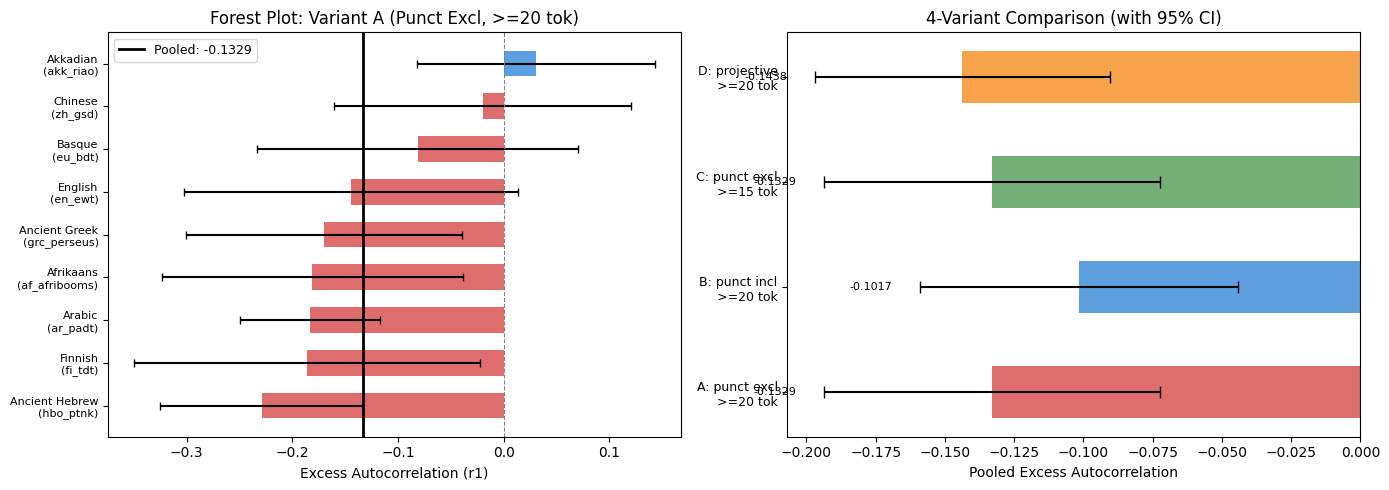

Figure saved to robustness_4variant_results.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Forest plot for variant A ---
ax = axes[0]
meta_a = meta_results.get("A", {})
if "per_treebank_effects" in meta_a:
    effects = meta_a["per_treebank_effects"]
    tb_names = []
    tb_effects_vals = []
    tb_errors = []
    for tb_id, eff_data in sorted(effects.items(), key=lambda x: x[1]["effect"]):
        lang = data["treebanks"].get(tb_id, {}).get("language", tb_id)
        tb_names.append(f"{lang}\n({tb_id})")
        tb_effects_vals.append(eff_data["effect"])
        tb_errors.append(1.96 * np.sqrt(eff_data["variance"]))

    y_pos = np.arange(len(tb_names))
    ax.barh(y_pos, tb_effects_vals, xerr=tb_errors, height=0.6,
            color=["#d32f2f" if e < 0 else "#1976d2" for e in tb_effects_vals],
            alpha=0.7, capsize=3)
    ax.axvline(x=0, color="gray", linestyle="--", linewidth=0.8)
    if "pooled_estimate" in meta_a:
        ax.axvline(x=meta_a["pooled_estimate"], color="black", linestyle="-",
                   linewidth=2, label=f"Pooled: {meta_a['pooled_estimate']:.4f}")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(tb_names, fontsize=8)
    ax.set_xlabel("Excess Autocorrelation (r1)")
    ax.set_title("Forest Plot: Variant A (Punct Excl, >=20 tok)")
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "No variant A results", ha="center", va="center", transform=ax.transAxes)

# --- Right: Variant comparison ---
ax2 = axes[1]
variant_labels = []
variant_pooled = []
variant_ci_low = []
variant_ci_high = []
variant_colors = ["#d32f2f", "#1976d2", "#388e3c", "#f57c00"]

for i, (v, label) in enumerate([
    ("A", "A: punct excl\n>=20 tok"),
    ("B", "B: punct incl\n>=20 tok"),
    ("C", "C: punct excl\n>=15 tok"),
    ("D", "D: projective\n>=20 tok"),
]):
    m = meta_results.get(v, {})
    if "pooled_estimate" in m:
        variant_labels.append(label)
        variant_pooled.append(m["pooled_estimate"])
        variant_ci_low.append(m["pooled_ci_lower"])
        variant_ci_high.append(m["pooled_ci_upper"])

if variant_pooled:
    y_pos2 = np.arange(len(variant_labels))
    pooled_arr = np.array(variant_pooled)
    ci_low_arr = np.array(variant_ci_low)
    ci_high_arr = np.array(variant_ci_high)
    xerr = np.array([pooled_arr - ci_low_arr, ci_high_arr - pooled_arr])
    ax2.barh(y_pos2, pooled_arr, xerr=xerr, height=0.5,
             color=variant_colors[:len(variant_labels)], alpha=0.7, capsize=4)
    ax2.axvline(x=0, color="gray", linestyle="--", linewidth=0.8)
    ax2.set_yticks(y_pos2)
    ax2.set_yticklabels(variant_labels, fontsize=9)
    ax2.set_xlabel("Pooled Excess Autocorrelation")
    ax2.set_title("4-Variant Comparison (with 95% CI)")

    # Add value labels
    for i, (p, lo, hi) in enumerate(zip(variant_pooled, variant_ci_low, variant_ci_high)):
        ax2.text(min(lo, p) - 0.01, i, f"{p:.4f}", va="center", ha="right", fontsize=8)
else:
    ax2.text(0.5, 0.5, "No meta-analysis results", ha="center", va="center", transform=ax2.transAxes)

plt.tight_layout()
plt.savefig("robustness_4variant_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to robustness_4variant_results.png")